<a href="https://colab.research.google.com/github/arsyadfillah/bigdata-project/blob/main/Final_project_bigdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/Bigdata')

['yelp_dataset.tar']

In [ ]:
tar_path = "/content/drive/MyDrive/Bigdata/yelp_dataset.tar"

In [ ]:
import os

size = os.path.getsize("/content/drive/MyDrive/Bigdata/yelp_dataset.tar")

print(f"{size/1024/1024/1024:.2f} GB")

4.05 GB


# Extract Dataset

In [ ]:
import tarfile

tar_path = "/content/drive/MyDrive/Bigdata/yelp_dataset.tar"

extract_path = "/content/yelp"

with tarfile.open(tar_path) as tar:
    tar.extractall(extract_path)

print("Extract selesai")

/tmp/ipykernel_5001/2129834579.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extract selesai


In [ ]:
import os

for file in os.listdir("/content/yelp"):
    print(file)

yelp_academic_dataset_tip.json
yelp_academic_dataset_checkin.json
yelp_academic_dataset_review.json
Dataset_User_Agreement.pdf
yelp_academic_dataset_business.json
yelp_academic_dataset_user.json


# Load Pyspark

In [ ]:

!pip install pyspark -q

Create Spark Session

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("YelpSentimentAnalysis") \
    .getOrCreate()

Load Review Dataset

In [ ]:
review_df = spark.read.json(
    "/content/yelp/yelp_academic_dataset_review.json"
)

Check Structure Dataset

In [ ]:
review_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)



In [ ]:
review_df.count()



6990280

In [ ]:
review_df.show(5, truncate=False)

+----------------------+----+-------------------+-----+----------------------+-----+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------------------+
|business_id           |cool|date               |fu

In [ ]:
print(len(review_df.columns))
print(review_df.columns)

9
['business_id', 'cool', 'date', 'funny', 'review_id', 'stars', 'text', 'useful', 'user_id']


# EDA (Exploratory Data Analysis).


In [ ]:
print("Jumlah Review :", review_df.count())
print("Jumlah Kolom  :", len(review_df.columns))

Jumlah Review : 6990280
Jumlah Kolom  : 9


In [ ]:
#Distribusi Rating
review_df.groupBy("stars") \
         .count() \
         .orderBy("stars") \
         .show()

+-----+-------+
|stars|  count|
+-----+-------+
|  1.0|1069561|
|  2.0| 544240|
|  3.0| 691934|
|  4.0|1452918|
|  5.0|3231627|
+-----+-------+



In [ ]:
#Missing Value Check
from pyspark.sql.functions import col, count, when

review_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in review_df.columns
]).show()

+-----------+----+----+-----+---------+-----+----+------+-------+
|business_id|cool|date|funny|review_id|stars|text|useful|user_id|
+-----------+----+----+-----+---------+-----+----+------+-------+
|          0|   0|   0|    0|        0|    0|   0|     0|      0|
+-----------+----+----+-----+---------+-----+----+------+-------+



In [ ]:
#Check Length Review
from pyspark.sql.functions import length

review_df.select(
    length("text").alias("review_length")
).describe().show()

+-------+-----------------+
|summary|    review_length|
+-------+-----------------+
|  count|          6990280|
|   mean|567.7644364746477|
| stddev|527.2578085249028|
|    min|                1|
|    max|             5000|
+-------+-----------------+



In [ ]:
#Labeling Stars
from pyspark.sql.functions import when

review_df = review_df.withColumn(
    "sentiment",
    when(col("stars") <= 2, "negative")
    .when(col("stars") == 3, "neutral")
    .otherwise("positive")
)

In [ ]:
#Verify Label Sentiment
review_df.groupBy("sentiment") \
         .count() \
         .orderBy("sentiment") \
         .show()

+---------+-------+
|sentiment|  count|
+---------+-------+
| negative|1613801|
|  neutral| 691934|
| positive|4684545|
+---------+-------+



In [ ]:
#create new dataframe
review_df = review_df.select(
    "business_id",
    "date",
    "stars",
    "text",
    "sentiment"
)

review_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- sentiment: string (nullable = false)



# Cleaning Text with Spark

In [ ]:
from pyspark.sql.functions import lower
from pyspark.sql.functions import regexp_replace

In [ ]:
clean_df = review_df.withColumn(
    "clean_text",
    lower("text")
)

clean_df = clean_df.withColumn(
    "clean_text",
    regexp_replace("clean_text", r"http\S+", "")
)

clean_df = clean_df.withColumn(
    "clean_text",
    regexp_replace("clean_text", r"[^a-zA-Z\s]", "")
)

clean_df = clean_df.withColumn(
    "clean_text",
    regexp_replace("clean_text", r"\s+", " ")
)

In [ ]:
#Check result cleaning
clean_df.select(
    "text",
    "clean_text"
).show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Encode Label Sentimen

In [ ]:
from pyspark.sql.functions import when

clean_df = clean_df.withColumn(
    "label",
    when(clean_df.sentiment == "negative", 0)
    .when(clean_df.sentiment == "neutral", 1)
    .otherwise(2)
)

# Train Test Split

In [ ]:
train_df, test_df = clean_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [ ]:
print(train_df.count())
print(test_df.count())

5591048
1399232


Distribution Sentiment

In [ ]:
review_df.groupBy("sentiment") \
         .count() \
         .show()

+---------+-------+
|sentiment|  count|
+---------+-------+
| positive|4684545|
|  neutral| 691934|
| negative|1613801|
+---------+-------+



In [ ]:
sentiment_dist = (
    review_df.groupBy("sentiment")
             .count()
             .toPandas()
)

sentiment_dist

,sentiment,count
0,positive,4684545
1,neutral,691934
2,negative,1613801


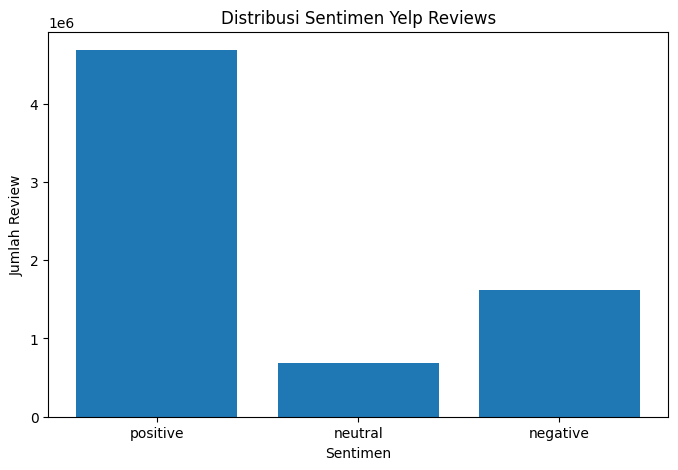

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    sentiment_dist["sentiment"],
    sentiment_dist["count"]
)

plt.title("Distribusi Sentimen Yelp Reviews")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Review")

plt.show()

Distribution Rating

In [ ]:
rating_dist = (
    review_df.groupBy("stars")
             .count()
             .orderBy("stars")
             .toPandas()
)

rating_dist

,stars,count
0,1.0,1069561
1,2.0,544240
2,3.0,691934
3,4.0,1452918
4,5.0,3231627


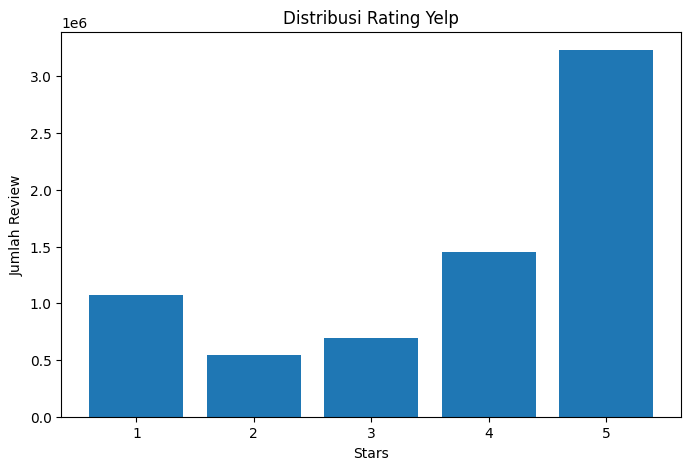

In [ ]:
#Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    rating_dist["stars"],
    rating_dist["count"]
)

plt.title("Distribusi Rating Yelp")
plt.xlabel("Stars")
plt.ylabel("Jumlah Review")

plt.show()

# Save cleaned data as parquet

In [ ]:
clean_df.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/Bigdata/yelp_cleaned"
)

Optimization for training

In [ ]:
train_df.cache()
test_df.cache()

DataFrame[business_id: string, date: string, stars: double, text: string, sentiment: string, clean_text: string, label: int]

In [ ]:
train_df.count()
test_df.count()

1399232

Tokenizer

In [ ]:
from pyspark.ml.feature import Tokenizer
from pyspark.ml.feature import StopWordsRemover
from pyspark.ml.feature import HashingTF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

In [ ]:
tokenizer = Tokenizer(
    inputCol="clean_text",
    outputCol="words"
)

StopWordsRemover

In [ ]:
stopwords = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

HashingTF

In [ ]:
hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="features",
    numFeatures=10000
)

Logistic Regression

In [ ]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=10
)


In [ ]:
pipeline = Pipeline(
    stages=[
        tokenizer,
        stopwords,
        hashingTF,
        lr
    ]
)

In [ ]:
model = pipeline.fit(train_df)

In [ ]:
predictions = model.transform(test_df)

In [ ]:
predictions.select(
    "text",
    "sentiment",
    "label",
    "prediction"
).show(10, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+-----+----------+
|text                                                                                                                                                                                                                                                                                                              

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8622158441202031


In [ ]:
f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print("F1 Score:", f1)

F1 Score: 0.8466371596449507


In [ ]:
precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(predictions)

print("Precision:", precision)

Precision: 0.8428394920776974


In [ ]:
recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(predictions)

print("Recall:", recall)

Recall: 0.862215844120203


In [ ]:
predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0|271896|
|    0|       1.0| 14091|
|    0|       2.0| 36445|
|    1|       0.0| 37013|
|    1|       1.0| 33529|
|    1|       2.0| 67788|
|    2|       0.0| 21147|
|    2|       1.0| 16308|
|    2|       2.0|901015|
+-----+----------+------+



In [ ]:
cm = predictions.groupBy(
    "label",
    "prediction"
).count().toPandas()

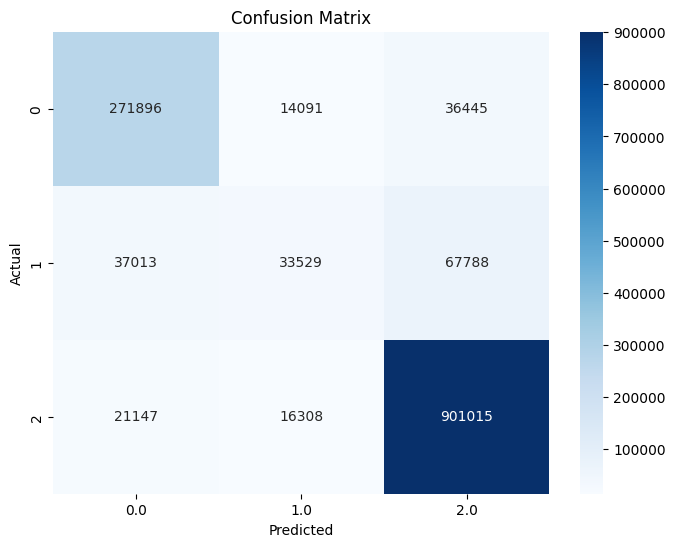

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cm_matrix = cm.pivot(
    index="label",
    columns="prediction",
    values="count"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

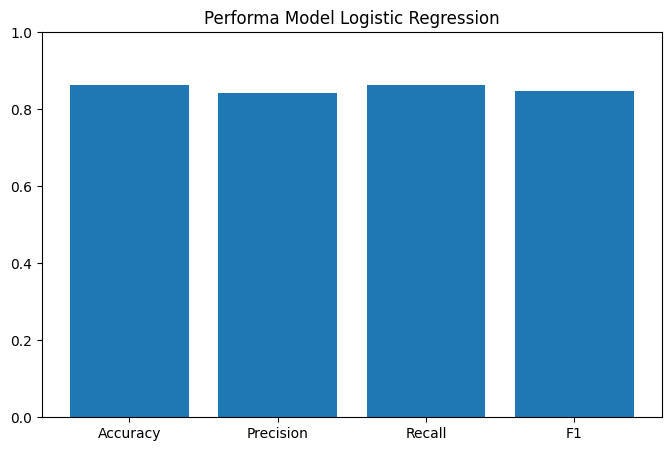

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

plt.figure(figsize=(8,5))

plt.bar(
    metrics["Metric"],
    metrics["Score"]
)

plt.ylim(0,1)

plt.title("Performa Model Logistic Regression")

plt.show()
